# Week 17 - Sample Final Code
During week 17, we will review the code you learned in this class.  The final exam will be based on knowing this code.

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Reading a dataset


In [195]:
data = pd.read_csv("ChronicKidneyDisease.csv")


# Display Data structure


In [196]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [197]:
data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [198]:
data.drop('id', axis = 1, inplace = True)

# Time for you to shine
- In the code cells below, add new columns
- If the missing values are not np.nan change them to np.nan
- Any other thing you wish to do to your dataset before splitting it into train and test datasets do here.  Add code cell if necessary.

In [233]:
LO = ['rbc', 'pc', 'pcc', 'ba','pcv', 'wc', 'rc', 'htn', 'dm','cad', 'appet', 'pe', 'ane', 'classification']
for i in LO:
    print(i)
    print(data[i].unique())

rbc
[nan 'normal' 'abnormal']
pc
['normal' 'abnormal' nan]
pcc
['notpresent' 'present' nan]
ba
['notpresent' 'present' nan]
pcv
[44. 38. 31. 32. 35. 39. 36. 33. 29. 28. nan 16. 24. 37. 30. 34. 40. 45.
 27. 48. 52. 14. 22. 18. 42. 17. 46. 23. 19. 25. 41. 26. 15. 21. 43. 20.
 47.  9. 49. 50. 53. 51. 54.]
wc
[ 7800.  6000.  7500.  6700.  7300.    nan  6900.  9600. 12100.  4500.
 12200. 11000.  3800. 11400.  5300.  9200.  6200.  8300.  8400. 10300.
  9800.  9100.  7900.  6400.  8600. 18900. 21600.  4300.  8500. 11300.
  7200.  7700. 14600.  6300.  7100. 11800.  9400.  5500.  5800. 13200.
 12500.  5600.  7000. 11900. 10400. 10700. 12700.  6800.  6500. 13600.
 10200.  9000. 14900.  8200. 15200.  5000. 16300. 12400. 10500.  4200.
  4700. 10900.  8100.  9500.  2200. 12800. 11200. 19100. 12300. 16700.
  2600. 26400.  8800.  7400.  4900.  8000. 12000. 15700.  4100.  5700.
 11500.  5400. 10800.  9900.  5200.  5900.  9300.  9700.  5100.  6600.]
rc
[5.2 nan 3.9 4.6 4.4 5.  4.  3.7 3.8 3.4 2.6 2.8 4

In [201]:
data.loc[data['pcv'] == "\t?", "pcv"] = np.nan
data.loc[data['pcv'] == '\t43', 'pcv'] = '43'
data['pcv'] = data['pcv'].astype(float, errors = 'ignore')
data['pcv'].unique()

array([44., 38., 31., 32., 35., 39., 36., 33., 29., 28., nan, 16., 24.,
       37., 30., 34., 40., 45., 27., 48., 52., 14., 22., 18., 42., 17.,
       46., 23., 19., 25., 41., 26., 15., 21., 43., 20., 47.,  9., 49.,
       50., 53., 51., 54.])

In [202]:
data.loc[data['wc'] == '\t6200', 'wc'] = '6200'
data.loc[data['wc'] == '\t8400', 'wc'] = '8400'
data.loc[data['wc'] == '\t?', 'wc'] = np.nan
data['wc'] = data['wc'].astype(float, errors = 'ignore')
data['wc'].unique()

array([ 7800.,  6000.,  7500.,  6700.,  7300.,    nan,  6900.,  9600.,
       12100.,  4500., 12200., 11000.,  3800., 11400.,  5300.,  9200.,
        6200.,  8300.,  8400., 10300.,  9800.,  9100.,  7900.,  6400.,
        8600., 18900., 21600.,  4300.,  8500., 11300.,  7200.,  7700.,
       14600.,  6300.,  7100., 11800.,  9400.,  5500.,  5800., 13200.,
       12500.,  5600.,  7000., 11900., 10400., 10700., 12700.,  6800.,
        6500., 13600., 10200.,  9000., 14900.,  8200., 15200.,  5000.,
       16300., 12400., 10500.,  4200.,  4700., 10900.,  8100.,  9500.,
        2200., 12800., 11200., 19100., 12300., 16700.,  2600., 26400.,
        8800.,  7400.,  4900.,  8000., 12000., 15700.,  4100.,  5700.,
       11500.,  5400., 10800.,  9900.,  5200.,  5900.,  9300.,  9700.,
        5100.,  6600.])

In [203]:
data.loc[data['rc'] == '\t?', 'rc'] = np.nan
data['rc'] = data['rc'].astype(float, errors = 'ignore')
data['rc'].unique()

array([5.2, nan, 3.9, 4.6, 4.4, 5. , 4. , 3.7, 3.8, 3.4, 2.6, 2.8, 4.3,
       3.2, 3.6, 4.1, 4.9, 2.5, 4.2, 4.5, 3.1, 4.7, 3.5, 6. , 2.1, 5.6,
       2.3, 2.9, 2.7, 8. , 3.3, 3. , 2.4, 4.8, 5.4, 6.1, 6.2, 6.3, 5.1,
       5.8, 5.5, 5.3, 6.4, 5.7, 5.9, 6.5])

In [204]:
data.loc[data['dm'] == '\tno', 'dm'] = 'no'
data.loc[data['dm'] == '\tyes', 'dm'] = 'yes'
data.loc[data['dm'] == ' yes', 'dm'] = 'yes'
data['dm'].unique()

array(['yes', 'no', nan], dtype=object)

In [205]:
data.loc[data['cad'] == '\tno', 'cad'] = 'no'
data['cad'].unique()

array(['no', 'yes', nan], dtype=object)

In [206]:
data.loc[data['classification'] == 'ckd\t', 'classification'] = 'ckd'
data['classification'].unique()

array(['ckd', 'notckd'], dtype=object)

In [207]:
LO = ['rbc', 'pc', 'pcc', 'ba','pcv', 'wc', 'rc', 'htn', 'dm','cad', 'appet', 'pe', 'ane', 'classification']
for i in LO:
    print(i)
    print(data[i].unique())

rbc
[nan 'normal' 'abnormal']
pc
['normal' 'abnormal' nan]
pcc
['notpresent' 'present' nan]
ba
['notpresent' 'present' nan]
pcv
[44. 38. 31. 32. 35. 39. 36. 33. 29. 28. nan 16. 24. 37. 30. 34. 40. 45.
 27. 48. 52. 14. 22. 18. 42. 17. 46. 23. 19. 25. 41. 26. 15. 21. 43. 20.
 47.  9. 49. 50. 53. 51. 54.]
wc
[ 7800.  6000.  7500.  6700.  7300.    nan  6900.  9600. 12100.  4500.
 12200. 11000.  3800. 11400.  5300.  9200.  6200.  8300.  8400. 10300.
  9800.  9100.  7900.  6400.  8600. 18900. 21600.  4300.  8500. 11300.
  7200.  7700. 14600.  6300.  7100. 11800.  9400.  5500.  5800. 13200.
 12500.  5600.  7000. 11900. 10400. 10700. 12700.  6800.  6500. 13600.
 10200.  9000. 14900.  8200. 15200.  5000. 16300. 12400. 10500.  4200.
  4700. 10900.  8100.  9500.  2200. 12800. 11200. 19100. 12300. 16700.
  2600. 26400.  8800.  7400.  4900.  8000. 12000. 15700.  4100.  5700.
 11500.  5400. 10800.  9900.  5200.  5900.  9300.  9700.  5100.  6600.]
rc
[5.2 nan 3.9 4.6 4.4 5.  4.  3.7 3.8 3.4 2.6 2.8 4

In [208]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

# Categorical Variable Distribution
- Assign a categorical variable to the variable column name strafcol.  Choose a variable that you think should have the same percentage of records in train and test datasets.
- Determine the distribution of that column strafcol using the value_counts(normalize = True) * 100

In [209]:
LC = 'classification'
data[LC].value_counts(normalize = True) * 100

classification
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64

In [210]:
# Save Clean Dataset
data.to_csv("CleanCKD.csv", index = False)

# Split the data set into Train and Test


In [211]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size = 0.30, random_state = 42, stratify = data[LC])

# Statistical Summary

In [214]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,275.0,51.389091,16.452028,4.000,42.000,54.00,64.00,90.000
bp,272.0,76.323529,12.846458,50.000,70.000,80.00,80.00,140.000
sg,252.0,1.017560,0.005672,1.005,1.015,1.02,1.02,1.025
al,252.0,1.019841,1.343274,0.000,0.000,0.00,2.00,5.000
su,250.0,0.496000,1.159033,0.000,0.000,0.00,0.00,5.000
bgr,248.0,151.919355,85.454166,22.000,100.000,120.00,165.00,490.000
bu,268.0,56.373881,50.733583,1.500,27.000,40.50,61.75,391.000
sc,267.0,2.935206,4.785312,0.400,0.900,1.20,2.70,48.100
sod,220.0,137.672727,7.315598,104.000,135.000,138.00,141.25,163.000
pot,220.0,4.712727,3.770496,2.500,3.800,4.40,4.90,47.000


In [215]:
train_df.describe(include = 'object').T

,count,unique,top,freq
rbc,168,2,normal,131
pc,239,2,normal,186
pcc,276,2,notpresent,248
ba,276,2,notpresent,260
htn,280,2,no,183
dm,280,2,no,187
cad,280,2,no,259
appet,279,2,good,221
pe,279,2,no,226
ane,279,2,no,244


# Histogram

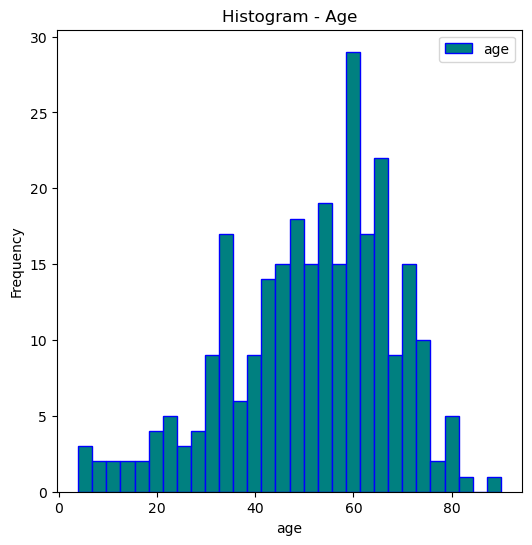

In [216]:
LC = 'age'
LT = 'Histogram - Age'
train_df.plot(y = LC, kind = "hist", 
              color = 'teal', edgecolor = 'blue', 
              title = LT, figsize = (6, 6), bins = 30,
              xlabel = LC, ylabel = 'Frequency');

    

# Scatterplot


<Axes: title={'center': 'Age vs White blood cell count'}, xlabel='age', ylabel='wc'>

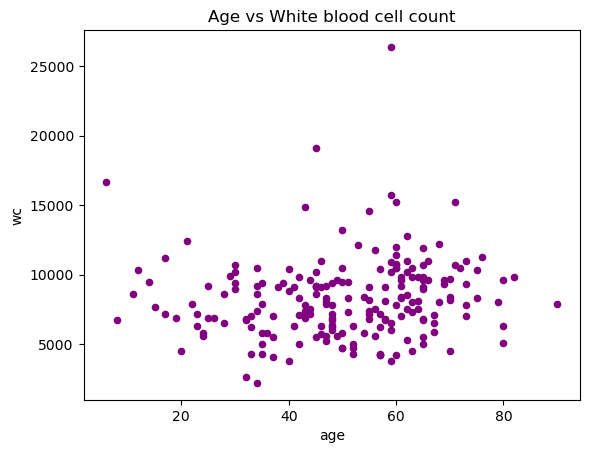

In [217]:
LX = 'age'
LY = 'wc'
LT = "Age vs White blood cell count"
train_df.plot.scatter(x = LX, y = LY, c ="purple", title = LT, xlabel = LX, ylabel = LY)

# Correlation Matrix


In [218]:
n_columns = train_df.select_dtypes(include = np.number).columns
cor_matrix = train_df[n_columns].corr()
cor_matrix

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
age,1.000000,0.208511,-0.223259,0.104709,0.257557,0.248320,0.171657,0.148552,-0.082590,0.043866,-0.166046,-0.203839,0.110947,-0.220561
bp,0.208511,1.000000,-0.209874,0.188432,0.139966,0.101714,0.187326,0.102674,-0.111316,0.081528,-0.336829,-0.358764,0.034977,-0.310903
sg,-0.223259,-0.209874,1.000000,-0.464411,-0.298269,-0.375260,-0.287840,-0.337666,0.394269,-0.077855,0.568587,0.578775,-0.163639,0.553222
al,0.104709,0.188432,-0.464411,1.000000,0.263942,0.379542,0.455523,0.345960,-0.414165,0.120900,-0.639371,-0.624217,0.245753,-0.544696
su,0.257557,0.139966,-0.298269,0.263942,1.000000,0.715169,0.205869,0.223467,-0.104932,0.237071,-0.201193,-0.228223,0.202024,-0.251608
bgr,0.248320,0.101714,-0.375260,0.379542,0.715169,1.000000,0.155432,0.102081,-0.305530,0.052855,-0.316672,-0.316639,0.160991,-0.300520
bu,0.171657,0.187326,-0.287840,0.455523,0.205869,0.155432,1.000000,0.644950,-0.286961,0.385267,-0.595315,-0.589259,0.041528,-0.563501
sc,0.148552,0.102674,-0.337666,0.345960,0.223467,0.102081,0.644950,1.000000,-0.332001,0.338734,-0.568261,-0.571534,0.021836,-0.589521
sod,-0.082590,-0.111316,0.394269,-0.414165,-0.104932,-0.305530,-0.286961,-0.332001,1.000000,0.132204,0.501410,0.500666,-0.000440,0.459789
pot,0.043866,0.081528,-0.077855,0.120900,0.237071,0.052855,0.385267,0.338734,0.132204,1.000000,-0.117046,-0.147775,-0.124951,-0.155918


# Save the train and test datasets

In [219]:
train_df.to_csv("train.csv", index = False)
test_df.to_csv("test.csv", index = False)

# Separate features and target variable

In [220]:
X = train_df.drop('classification', axis = 1)
y = train_df['classification']

X_test = test_df.drop('classification', axis = 1)
y_test = test_df['classification']

# Numeric Pipeline

In [221]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

n_features = X.select_dtypes(include = np.number).columns
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),  
    ('scaler', StandardScaler())])   

# Categorical Pipeline

In [222]:
from sklearn.preprocessing import OneHotEncoder

cat_features = X.select_dtypes(include = ['object']).columns
cat_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy = 'most_frequent')),
     ('onehot', OneHotEncoder(handle_unknown = 'ignore'))])

# Data Preprocessing Pipeline

In [223]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transformer, n_features),
    ('cat', cat_transformer, cat_features)])

# Logistic Regression Pipeline

In [224]:
from sklearn.linear_model import LogisticRegression

l_pipeline = Pipeline([
           ('preprocessor', preprocessor),
           ('clf', LogisticRegression(random_state = 42))])

# K-Nearest Neighbor


In [225]:
from sklearn.neighbors import KNeighborsClassifier

k_pipeline = Pipeline([
           ('preprocessor', preprocessor),
           ('clf', KNeighborsClassifier(n_neighbors = 5))])           

# Cross Valuation 

In [226]:
from sklearn.model_selection import cross_val_score, cross_val_predict

cv_score = cross_val_score(l_pipeline, X, y, cv = 5)
y_cv_prd = cross_val_predict(l_pipeline, X, y, cv = 5)

# Classification Report


In [227]:
from sklearn.metrics import classification_report

print(classification_report(y, y_cv_prd, target_names = ['Died', 'Survived']))

              precision    recall  f1-score   support

        Died       0.99      0.99      0.99       175
    Survived       0.99      0.99      0.99       105

    accuracy                           0.99       280
   macro avg       0.99      0.99      0.99       280
weighted avg       0.99      0.99      0.99       280



# Overfitting
If metric score for train - metric score for test > 0.10 then overfitting.<br>
If metric score for train - metric score for test <= 0.10 then "good generalization."


# Decision Tree


In [228]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth = 3, random_state = 42))])

# Random Forest

In [229]:
from sklearn.ensemble import RandomForestClassifier

randomforest_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('rf', RandomForestClassifier(n_estimators = 100, random_state = 42))])

# Extra Trees


In [230]:
from sklearn.ensemble import ExtraTreesClassifier

extraTree_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('et', ExtraTreesClassifier(n_estimators = 100, random_state = 42))])

# KMeans Pipeline

In [231]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

kmeans_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')), 
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('kmeans', KMeans(random_state = 42, n_init = 10))])
    

# ANN Pipeline

In [232]:
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('ann', MLPClassifier(
    hidden_layer_sizes = (16, 8), # Two hidden layers: 16 neurons and 8 neurons
    activation = 'relu',          # Common 'rectified linear unit' activation
    solver = 'adam',              # The optimizer (how it learns)
    max_iter = 500,               # Maximum number of epochs
    random_state = 42))])

# Linear Regression Model
```
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

l_reg = make_pipeline(preprocessor, 
                    TransformedTargetRegressor(LinearRegression(),
                    transformer = StandardScaler()))

l_reg.fit(X_train,y_train)

y_pd_train = l_reg.predict(X_train)
l_reg_rmse_train = np.sqrt(mean_squared_error(y_train, y_pd_train))

y_pd_test = l_reg.predict(X_test)
l_reg_rmse_test = np.sqrt(mean_squared_error(y_test, y_pd_test))

```


# Ridge Regression Model
```
from sklearn.linear_model import Ridge

r_reg = make_pipeline(preprocessor, 
             TransformedTargetRegressor(Ridge(),
             transformer = StandardScaler()))
```

# Lasso Regression Model

```
from sklearn.linear_model import Lasso

las_reg = make_pipeline(preprocessor, 
                        TransformedTargetRegressor(Lasso(),
                        transformer = StandardScaler()))
```

# ElasticNet Regression Model
```
from sklearn.linear_model import ElasticNet

en_reg = make_pipeline(preprocessor, 
        TransformedTargetRegressor(regressor = ElasticNet(),
        transformer = StandardScaler()))
```